# playing with wattnet

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# help from https://realpython.com/api-integration-in-python/
# https://stackoverflow.com/questions/70254557/error-received-when-using-an-api-get-request-with-json-and-python

In [ ]:
payload = {'key1': 'value1', 'key2': 'value2'}
r = requests.get('https://httpbin.org/get', params=payload)
print(r.url)

In [20]:
api_url = 'https://api.wattnet.eu/v1/zones'
r = requests.get(api_url)
print(r.url)

https://auth.wattnet.eu/realms/wattnet/protocol/openid-connect/auth?approval_prompt=force&client_id=oauth2-proxy&redirect_uri=https%3A%2F%2Fapi.wattnet.eu%2Foauth2%2Fcallback&response_type=code&scope=openid+email+profile&state=8D-RUPKk2yIHj7rzlfaHEw6skq9HSqJPBvK1uHbc39s%3Ahttps%3A%2F%2Fapi.wattnet.eu%2Fv1%2Fzones


In [16]:
# Source - https://stackoverflow.com/a/35138180
# Posted by Padraic Cunningham, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-09, License - CC BY-SA 3.0

u_a = "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/48.0.2564.82 Safari/537.36"
#response = requests.get(url, headers={"USER-AGENT":u_a})


In [ ]:
api_url = "https://api.wattnet.eu/v1/load"
payload = {'zone':'IE', 'start':'2026-06-08', 'end':'2026-06-09'}
r = requests.post(api_url, params=payload, headers={"USER-AGENT":u_a})
print(r.url)
r.json()

In [ ]:
data = json.loads(r.text)
data

# can't seem to get the API to work, likely because I can't seem to generate a key from their site: https://api.wattnet.eu/token-request/

# load the data I was able to download by testing their API via https://api.wattnet.eu/v1/docs

In [2]:
filename = '../E2EGHG/wattnet-data/load.json'
df = pd.read_json(filename)
df

,zone,unit,series
0,IE,MW,"[{'valid': True, 'zone_status': 'complete', 'b..."


In [3]:
with open(filename, "r") as read_it:
     data = json.load(read_it)

print(data)

[{'zone': 'IE', 'unit': 'MW', 'series': [{'valid': True, 'zone_status': 'complete', 'blocks': [{'data_state': 'official', 'datasource': 'ENTSO-E', 'values': [['2026-06-08T00:00:00Z', 3227.84], ['2026-06-08T00:15:00Z', 3227.84], ['2026-06-08T00:30:00Z', 3184.4], ['2026-06-08T00:45:00Z', 3184.4], ['2026-06-08T01:00:00Z', 3162.81], ['2026-06-08T01:15:00Z', 3162.81], ['2026-06-08T01:30:00Z', 3252.46], ['2026-06-08T01:45:00Z', 3252.46], ['2026-06-08T02:00:00Z', 3203.57], ['2026-06-08T02:15:00Z', 3203.57], ['2026-06-08T02:30:00Z', 3172.61], ['2026-06-08T02:45:00Z', 3172.61], ['2026-06-08T03:00:00Z', 3102.41], ['2026-06-08T03:15:00Z', 3102.41], ['2026-06-08T03:30:00Z', 3096.53], ['2026-06-08T03:45:00Z', 3096.53], ['2026-06-08T04:00:00Z', 3083.17], ['2026-06-08T04:15:00Z', 3083.17], ['2026-06-08T04:30:00Z', 3114.64], ['2026-06-08T04:45:00Z', 3114.64], ['2026-06-08T05:00:00Z', 3197.73], ['2026-06-08T05:15:00Z', 3197.73], ['2026-06-08T05:30:00Z', 3377.84], ['2026-06-08T05:45:00Z', 3377.84], ['20

In [51]:
parsed = data[0]['series'][0]['blocks'][0]['values']
print(parsed)

[['2026-06-08T00:00:00Z', 3227.84], ['2026-06-08T00:15:00Z', 3227.84], ['2026-06-08T00:30:00Z', 3184.4], ['2026-06-08T00:45:00Z', 3184.4], ['2026-06-08T01:00:00Z', 3162.81], ['2026-06-08T01:15:00Z', 3162.81], ['2026-06-08T01:30:00Z', 3252.46], ['2026-06-08T01:45:00Z', 3252.46], ['2026-06-08T02:00:00Z', 3203.57], ['2026-06-08T02:15:00Z', 3203.57], ['2026-06-08T02:30:00Z', 3172.61], ['2026-06-08T02:45:00Z', 3172.61], ['2026-06-08T03:00:00Z', 3102.41], ['2026-06-08T03:15:00Z', 3102.41], ['2026-06-08T03:30:00Z', 3096.53], ['2026-06-08T03:45:00Z', 3096.53], ['2026-06-08T04:00:00Z', 3083.17], ['2026-06-08T04:15:00Z', 3083.17], ['2026-06-08T04:30:00Z', 3114.64], ['2026-06-08T04:45:00Z', 3114.64], ['2026-06-08T05:00:00Z', 3197.73], ['2026-06-08T05:15:00Z', 3197.73], ['2026-06-08T05:30:00Z', 3377.84], ['2026-06-08T05:45:00Z', 3377.84], ['2026-06-08T06:00:00Z', 3577.26], ['2026-06-08T06:15:00Z', 3577.26], ['2026-06-08T06:30:00Z', 3842.28], ['2026-06-08T06:45:00Z', 3842.28], ['2026-06-08T07:00:00

In [4]:
# Normalize the data
#from pandas.io.json import json_normalize
# help from https://www.slingacademy.com/article/pandas-how-to-parse-a-json-file-into-a-dataframe/#basic-json-parsing
# and https://stackoverflow.com/questions/76083428/importerror-cannot-import-name-json-normalize-from-pandas-io-json
normalized_df = pd.json_normalize(data[0]['series'][0]['blocks'][0], 'values')

# Display the DataFrame
normalized_df.reset_index(inplace=True, drop=True)
normalized_df

,0,1
0,2026-06-08T00:00:00Z,3227.84
1,2026-06-08T00:15:00Z,3227.84
2,2026-06-08T00:30:00Z,3184.40
3,2026-06-08T00:45:00Z,3184.40
4,2026-06-08T01:00:00Z,3162.81
...,...,...
91,2026-06-08T22:45:00Z,3638.33
92,2026-06-08T23:00:00Z,3527.37
93,2026-06-08T23:15:00Z,3527.37
94,2026-06-08T23:30:00Z,3449.55


In [5]:
# rename columns
normalized_df.columns = ['datetime','load (MW)']
df_load = normalized_df
df_load['datetime'] = pd.to_datetime(df_load['datetime']).dt.tz_localize(None)
df_load['time'] = df_load['datetime'].dt.time
df_load.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   datetime   96 non-null     datetime64[us]
 1   load (MW)  96 non-null     float64       
 2   time       96 non-null     object        
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 2.4+ KB


In [100]:
df_load.head(50)

,datetime,load (MW),time
0,2026-06-08 00:00:00,3227.84,00:00:00
1,2026-06-08 00:15:00,3227.84,00:15:00
2,2026-06-08 00:30:00,3184.40,00:30:00
3,2026-06-08 00:45:00,3184.40,00:45:00
4,2026-06-08 01:00:00,3162.81,01:00:00
5,2026-06-08 01:15:00,3162.81,01:15:00
6,2026-06-08 01:30:00,3252.46,01:30:00
7,2026-06-08 01:45:00,3252.46,01:45:00
8,2026-06-08 02:00:00,3203.57,02:00:00
9,2026-06-08 02:15:00,3203.57,02:15:00


Text(0.5, 0, 'time (15 min increments)')

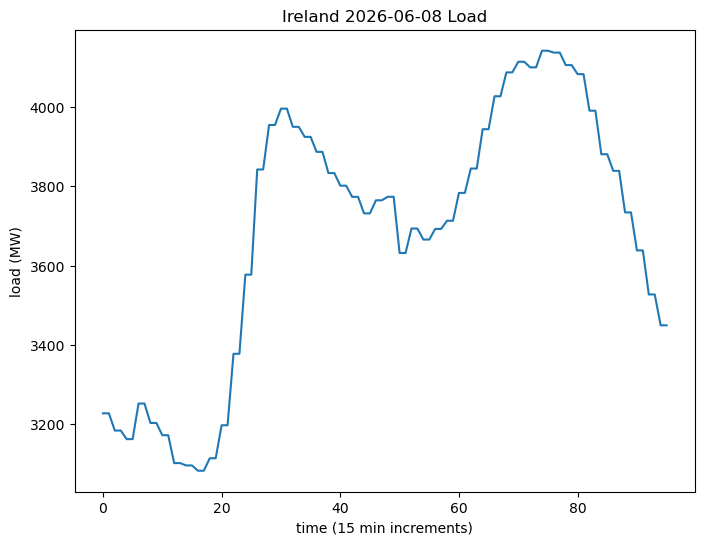

In [6]:
# plot the day of load
plt.figure(figsize=(8,6))
sns.lineplot(data=df_load, x=df_load.index, y='load (MW)')
plt.title("Ireland 2026-06-08 Load")
plt.xlabel('time (15 min increments)')

## Load and Footprint plots over 2026-06-03 to 2026-06-09

In [7]:
filename = '../E2EGHG/wattnet-data/20260603-20260609_load.json'

In [8]:
with open(filename, "r") as read_it:
     data = json.load(read_it)

In [9]:
# Normalize the data
normalized_df = pd.json_normalize(data[0]['series'][0]['blocks'][0], 'values')

# Display the DataFrame
normalized_df.reset_index(inplace=True, drop=True)
# rename columns
normalized_df.columns = ['datetime','load (MW)']
df_load = normalized_df
df_load['datetime'] = pd.to_datetime(df_load['datetime']).dt.tz_localize(None)
df_load['time'] = df_load['datetime'].dt.time
df_load.info()

<class 'pandas.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   datetime   528 non-null    datetime64[us]
 1   load (MW)  528 non-null    float64       
 2   time       528 non-null    object        
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 12.5+ KB


Text(0.5, 0, 'time (15 min increments)')

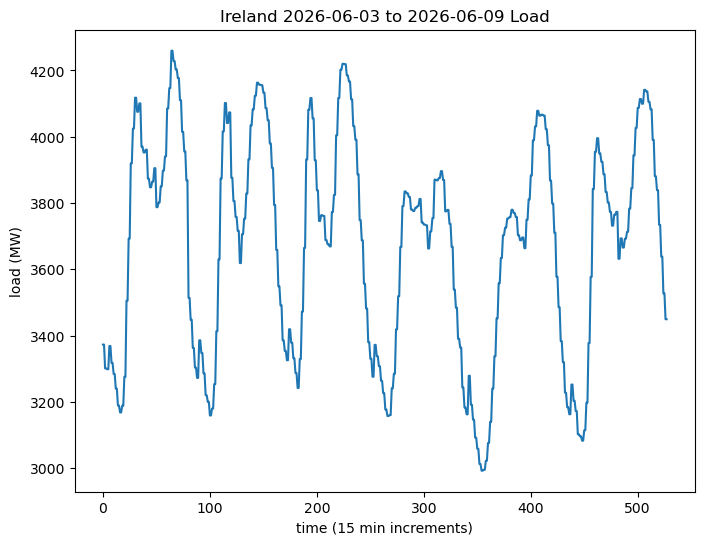

In [10]:
# plot the day of load
plt.figure(figsize=(8,6))
sns.lineplot(data=df_load, x=df_load.index, y='load (MW)')
plt.title("Ireland 2026-06-03 to 2026-06-09 Load")
plt.xlabel('time (15 min increments)')

In [126]:
df_load.head()

,datetime,load (MW),time
0,2026-06-03 00:00:00,3373.05,00:00:00
1,2026-06-03 00:15:00,3373.05,00:15:00
2,2026-06-03 00:30:00,3301.16,00:30:00
3,2026-06-03 00:45:00,3301.16,00:45:00
4,2026-06-03 01:00:00,3298.71,01:00:00


In [11]:
filename = '../E2EGHG/wattnet-data/20260603-20260609_operational_footprint.json'

In [12]:
with open(filename, "r") as read_it:
     data = json.load(read_it)

In [120]:
#data[0]['series'][0]['values']

In [13]:
# Normalize the data
normalized_df = pd.json_normalize(data[0]['series'][0], 'values')

# Display the DataFrame
normalized_df.reset_index(inplace=True, drop=True)
# rename columns
normalized_df.columns = ['datetime','footprint (gCO2/kWh)']
df_footprint = normalized_df
df_footprint['datetime'] = pd.to_datetime(df_footprint['datetime']).dt.tz_localize(None)
df_footprint['time'] = df_footprint['datetime'].dt.time
df_footprint.info()

<class 'pandas.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              552 non-null    datetime64[us]
 1   footprint (gCO2/kWh)  552 non-null    float64       
 2   time                  552 non-null    object        
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 13.1+ KB


In [125]:
df_footprint.head()

,datetime,footprint (gCO2/kWh),time
0,2026-06-03 00:00:00,203.62,00:00:00
1,2026-06-03 00:15:00,203.57,00:15:00
2,2026-06-03 00:30:00,173.65,00:30:00
3,2026-06-03 00:45:00,173.38,00:45:00
4,2026-06-03 01:00:00,158.85,01:00:00


Text(0.5, 0, 'time (15 min increments)')

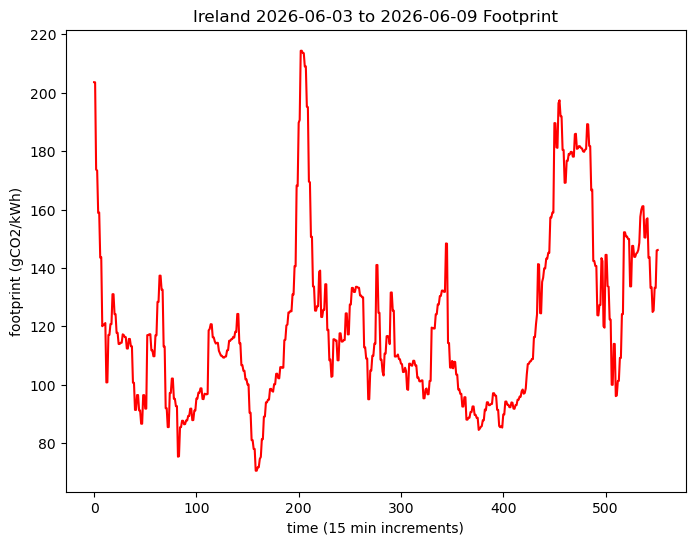

In [14]:
# plot the day of load
plt.figure(figsize=(8,6))
sns.lineplot(data=df_footprint, x=df_footprint.index, y='footprint (gCO2/kWh)', color='red')
plt.title("Ireland 2026-06-03 to 2026-06-09 Footprint")
plt.xlabel('time (15 min increments)')

In [16]:
# example of twin plot (left and right axis with diff scales) from https://stackoverflow.com/questions/55654500/seaborn-plot-with-second-y-axis
# fig, ax1 = plt.subplots() # initializes figure and plots

# ax2 = ax1.twinx() # applies twinx to ax2, which is the second y axis. 

# sns.barplot(x = x, y = y, ax = ax1, color = 'blue') # plots the first set of data, and sets it to ax1. 
# sns.lineplot(x = x, y = y1, marker = 'o', color = 'red', ax = ax2) # plots the second set, and sets to ax2. 

# # these lines add the annotations for the plot. 
# ax1.set_xlabel('X data')
# ax1.set_ylabel('Counts', color='g')
# ax2.set_ylabel('Detection Rates', color='b')

# plt.show()

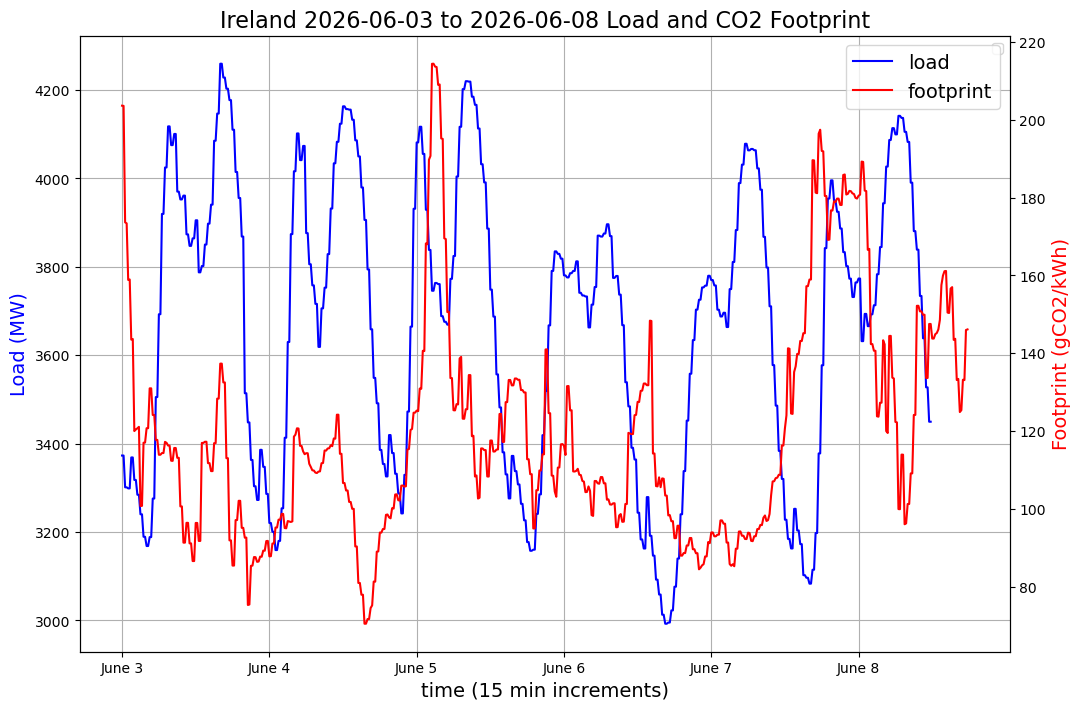

In [17]:
# combine into single plot
# help for legend from https://stackoverflow.com/questions/5484922/secondary-axis-with-twinx-how-to-add-to-legend

fig, ax1 = plt.subplots(figsize=(12,8)) # initializes figure and plots
ax2 = ax1.twinx() # applies twinx to ax2, which is the second y axis. 

sns.lineplot(data=df_load, x=df_load.index, y='load (MW)', color='blue', ax=ax1, label='load')
sns.lineplot(data=df_footprint, x=df_footprint.index, y='footprint (gCO2/kWh)', color='red', ax=ax2, label='footprint')

# ask matplotlib for the plotted objects and their labels
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc=0, fontsize=14)
ax1.legend("")
ax1.grid()

ax1.set_xlabel('time (15 min increments)', fontsize=14)
ax1.set_ylabel('Load (MW)', fontsize=14, color='blue')
ax2.set_ylabel('Footprint (gCO2/kWh)', fontsize=14, color='red')

ax1.set_xticks(np.arange(0,6*96,96))
ax1.set_xticklabels(['June 3', 'June 4', 'June 5', 'June 6', 'June 7','June 8'])
# plt.legend()
plt.title("Ireland 2026-06-03 to 2026-06-08 Load and CO2 Footprint", fontsize=16)

plt.show()